In [1]:
import numpy as np
import xarray as xr
import colormaps as cmaps
import pandas as pd

def calculate_KGE(simulated: xr.DataArray, observed: xr.DataArray) -> xr.DataArray:
    """
    Calculate the Kling-Gupta Efficiency (KGE) for simulated and observed time series
    for each grid cell (lon, lat).
    
    Parameters:
    simulated (xr.DataArray): The simulated time series (model output), with dimensions (time, lat, lon).
    observed (xr.DataArray): The observed time series, with dimensions (time, lat, lon).
    
    Returns:
    xr.DataArray: Kling-Gupta Efficiency (KGE) for each grid cell (lat, lon).
    """
    # Ensure that both arrays have the same shape
    if simulated.shape != observed.shape:
        raise ValueError("Simulated and observed arrays must have the same shape")

    # Calculate Pearson correlation coefficient (r) for each grid cell
    r = xr.corr(simulated, observed, dim='time')

    # Calculate the alpha term (ratio of standard deviations) for each grid cell
    alpha = simulated.std(dim='time') / observed.std(dim='time')

    # Calculate the beta term (ratio of means) for each grid cell
    beta = simulated.mean(dim='time') / observed.mean(dim='time')

    # Calculate the Kling-Gupta Efficiency (KGE) for each grid cell
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    return kge, r, alpha, beta

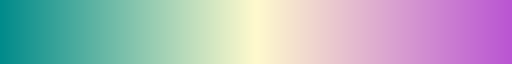

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["darkcyan","lemonchiffon","mediumorchid"])
cmap

In [5]:
def add_map(ax, data, cmap, vmin, vmax, cbar_label, extend, subplot_label, fontsize):
    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.axis('off')

    ax.text(0.01, 0.99, subplot_label, transform=ax.transAxes,
            fontsize=fontsize, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    
    return im  # Return the image so we can create a shared colorbar


In [6]:
def plot_triple_KGE_maps(kge1, r1, beta1, alpha1,
                        kge2, r2, beta2, alpha2,
                        kge3, r3, beta3, alpha3,
                        savedir):

    fig = plt.figure(figsize=(18, 18))
    gs = gridspec.GridSpec(4, 3, hspace=0.25, wspace=0.05)

    # === Row 1: KGE ===
    ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=11))
    im1 = add_map(ax1, kge1, cmaps.ice_r, -0.41, 1, "", 'min', 'a)', fontsize=14)

    ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=11))
    add_map(ax2, kge2, cmaps.ice_r, -0.41, 1, "", 'min', 'b)', fontsize=14)

    ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree(central_longitude=11))
    add_map(ax3, kge3, cmaps.ice_r, -0.41, 1, "", 'min', 'c)', fontsize=14)

    cax1 = fig.add_axes([0.2, 0.71, 0.6, 0.015])
    cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal', extend='min')
    cbar1.set_label("Kling-Gupta Efficiency", fontsize=14)
    cbar1.ax.tick_params(labelsize=12)

    # === Row 2: Correlation ===
    ax4 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=11))
    im2 = add_map(ax4, r1, cmaps.cmp_b2r_r, -1, 1, "", 'neither', 'd)', fontsize=12)

    ax5 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=11))
    add_map(ax5, r2, cmaps.cmp_b2r_r, -1, 1, "", 'neither', 'e)', fontsize=12)

    ax6 = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=11))
    add_map(ax6, r3, cmaps.cmp_b2r_r, -1, 1, "", 'neither', 'f)', fontsize=12)

    cax2 = fig.add_axes([0.2, 0.51, 0.6, 0.015])
    cbar2 = plt.colorbar(im2, cax=cax2, orientation='horizontal')
    cbar2.set_label("Correlation", fontsize=14)
    cbar2.ax.tick_params(labelsize=12)

    # === Row 3: Bias Ratio ===
    ax7 = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=11))
    im3 = add_map(ax7, beta1, cmap, 0, 2, "", 'max', 'g)', fontsize=12)

    ax8 = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree(central_longitude=11))
    add_map(ax8, beta2, cmap, 0, 2, "", 'max', 'h)', fontsize=12)

    ax9 = fig.add_subplot(gs[2, 2], projection=ccrs.PlateCarree(central_longitude=11))
    add_map(ax9, beta3, cmap, 0, 2, "", 'max', 'i)', fontsize=12)

    cax3 = fig.add_axes([0.2, 0.31, 0.6, 0.015])
    cbar3 = plt.colorbar(im3, cax=cax3, orientation='horizontal', extend='max')
    cbar3.set_label("Bias Ratio", fontsize=14)
    cbar3.ax.tick_params(labelsize=12)

    # === Row 4: Variability Ratio ===
    ax10 = fig.add_subplot(gs[3, 0], projection=ccrs.PlateCarree(central_longitude=11))
    im4 = add_map(ax10, alpha1, cmap, 0, 2, "", 'max', 'j)', fontsize=12)

    ax11 = fig.add_subplot(gs[3, 1], projection=ccrs.PlateCarree(central_longitude=11))
    add_map(ax11, alpha2, cmap, 0, 2, "", 'max', 'k)', fontsize=12)

    ax12 = fig.add_subplot(gs[3, 2], projection=ccrs.PlateCarree(central_longitude=11))
    add_map(ax12, alpha3, cmap, 0, 2, "", 'max', 'l)', fontsize=12)

    cax4 = fig.add_axes([0.2, 0.11, 0.6, 0.015])
    cbar4 = plt.colorbar(im4, cax=cax4, orientation='horizontal', extend='max')
    cbar4.set_label("Variability Ratio", fontsize=14)
    cbar4.ax.tick_params(labelsize=12)

    # === Column headers ===
    fig.text(0.2, 0.88, 'Baseline', fontsize=16, fontweight='bold', ha='center')
    fig.text(0.5, 0.88, 'Monthly mortality', fontsize=16, fontweight='bold', ha='center')
    fig.text(0.8, 0.88, 'Drought mortality', fontsize=16, fontweight='bold', ha='center')

    # === Horizontal separators ===
    for y in [0.67, 0.47, 0.27]:
        fig.lines.append(plt.Line2D([0.05, 0.95], [y, y],
                                   transform=fig.transFigure,
                                   color='gray', linewidth=0.8, linestyle='--'))

    plt.savefig(savedir, dpi=1200, bbox_inches='tight')
    plt.show()

In [9]:
import xarray as xr

kge_ds = xr.open_dataset("/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_03_27_global_droughtmort/check_output_with_fire/kgemetrics.nc")

kge_baseline = kge_ds["kge_baseline"]
kge_monthlymort = kge_ds["kge_monthlymort"]
kge_droughtmort = kge_ds["kge_droughtmort"]

r_baseline = kge_ds["r_baseline"]
r_monthlymort = kge_ds["r_monthlymort"]
r_droughtmort = kge_ds["r_droughtmort"]

alpha_baseline = kge_ds["alpha_baseline"]
alpha_monthlymort = kge_ds["alpha_monthlymort"]
alpha_droughtmort = kge_ds["alpha_droughtmort"]

beta_baseline = kge_ds["beta_baseline"]
beta_monthlymort = kge_ds["beta_monthlymort"]
beta_droughtmort = kge_ds["beta_droughtmort"]


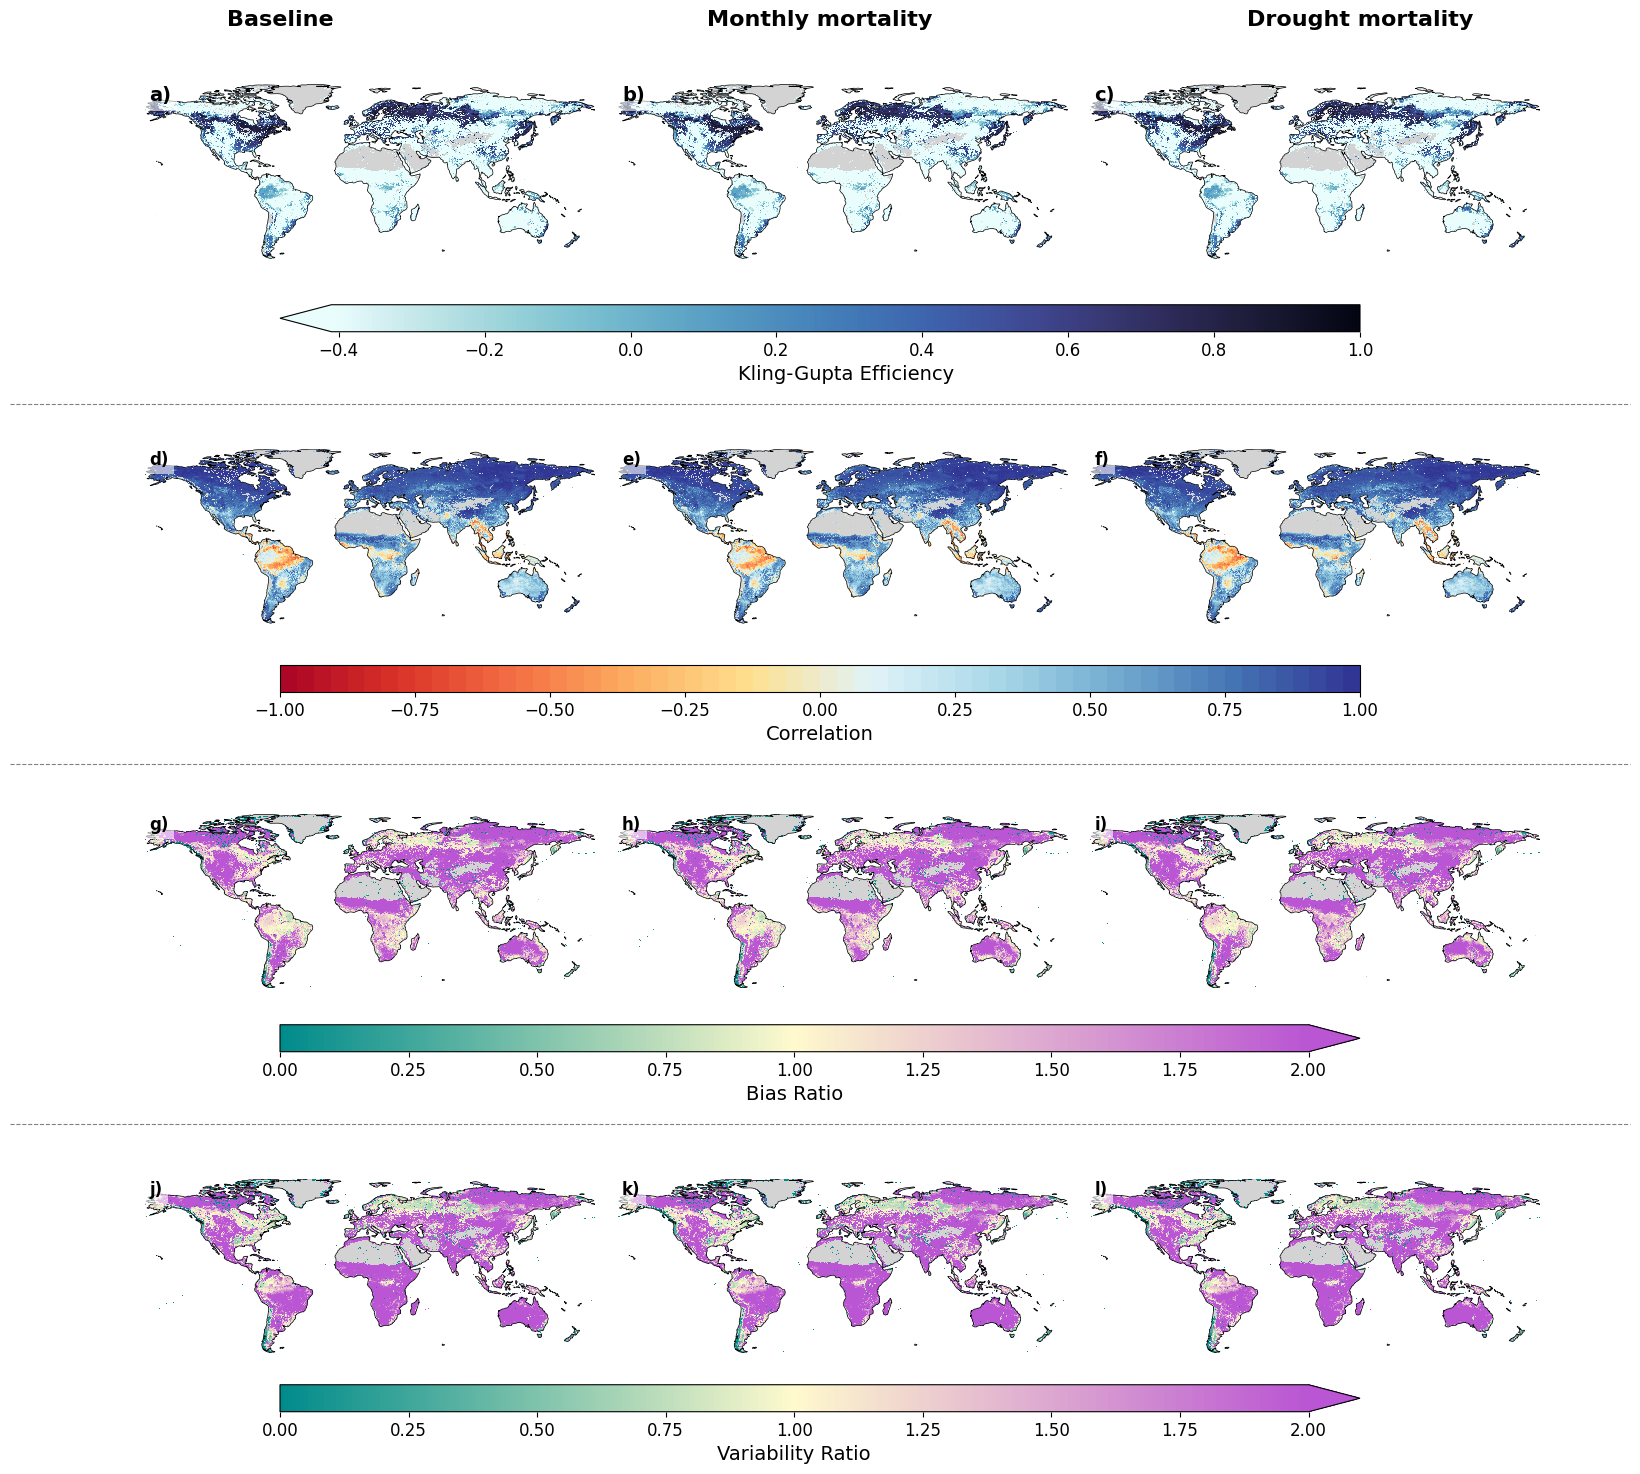

In [11]:
## Plot in one figure
plot_triple_KGE_maps(kge_baseline, r_baseline, beta_baseline, alpha_baseline,
                    kge_monthlymort, r_monthlymort, beta_monthlymort, alpha_monthlymort,
                    kge_droughtmort, r_droughtmort, beta_droughtmort, alpha_droughtmort,
                    savedir='/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_03_27_global_droughtmort/check_output_with_fire/kge_comparison.png')

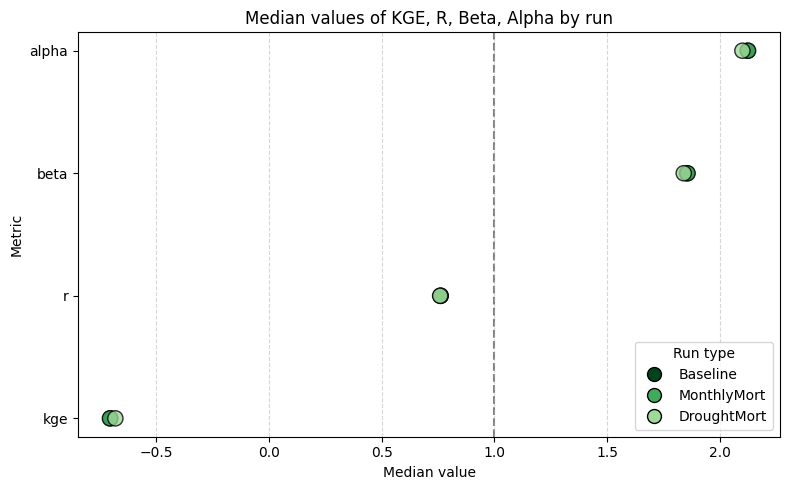

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# Example variable list
vars_to_check = [
    'kge_baseline','r_baseline','beta_baseline','alpha_baseline',
    'kge_monthlymort','r_monthlymort','beta_monthlymort','alpha_monthlymort',
    'kge_droughtmort','r_droughtmort','beta_droughtmort','alpha_droughtmort',
]

results = []

for name in vars_to_check:
    obj = globals().get(name)
    if obj is None:
        med = np.nan
        status = 'NOT FOUND'
    else:
        try:
            if isinstance(obj, xr.DataArray):
                med = float(obj.median(dim=None, skipna=True).item())
            else:
                med = float(np.nanmedian(obj))
            status = 'OK'
        except Exception as e:
            med = np.nan
            status = f'ERROR: {e}'
    # Extract metric and run
    if '_' in name:
        metric, run = name.split('_', 1)
        run_type_map = {'baseline':'Baseline', 'monthlymort':'MonthlyMort', 'droughtmort':'Calibrated'}
        run_type = run_type_map.get(run, run)
    else:
        metric, run_type = name, 'unknown'
    results.append({'metric': metric, 'Type': run_type, 'median': med, 'status': status})

df_meds = pd.DataFrame(results)

# Define colors
colors = {
    'Baseline': '#00441b',      # dark green
    'MonthlyMort': '#41ab5d',   # medium green
    'Calibrated': '#a1d99b'     # light green
}

# Map metric names to numeric y positions for plotting
metrics = df_meds['metric'].unique()
y_map = {metric:i for i, metric in enumerate(metrics)}
y_ticks = list(y_map.keys())
y_positions = list(y_map.values())

fig, ax = plt.subplots(figsize=(8,5))

for metric in metrics:
    subset = df_meds[df_meds['metric'] == metric].sort_values(
        'Type', key=lambda x: x.map({'Baseline':0,'MonthlyMort':1,'Calibrated':2})
    )
    x = subset['median'].values
    y = np.full_like(x, fill_value=y_map[metric], dtype=float)  # correct y positions
    c = [colors[t] for t in subset['Type']]
    
    # Draw gradient line connecting dots
    for i in range(len(x)-1):
        ax.plot(x[i:i+2], y[i:i+2], color=c[i], linewidth=2, zorder=1)
    
    # Draw dots with black edge
    ax.scatter(x, y, color=c, edgecolor='black', s=120, zorder=2, alpha=0.8)

ax.set_yticks(y_positions)
ax.set_yticklabels(y_ticks)
ax.set_xlabel('Median value')
ax.set_ylabel('Metric')
ax.set_title('Median values of KGE, R, Beta, Alpha by run')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.5, zorder=0)

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Baseline'], markeredgecolor='black', markersize=10, label='Baseline'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['MonthlyMort'], markeredgecolor='black', markersize=10, label='MonthlyMort'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Calibrated'], markeredgecolor='black', markersize=10, label='DroughtMort'),
]
ax.legend(handles=legend_handles, title='Run type', loc='lower right', frameon=True)
plt.tight_layout()
plt.show()